In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import morethemes as mt
mt.set_theme('economist')
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf
import fredapi as fp

# Organization
Nominal-wage data loading and dataset preparation (2012-2024).

# Preprocessing: 2012-2024 Panel Setup
Load and standardize professor salary files for the 2012-2024 analysis window.

In [5]:
# Load professor files for the project analysis window (2012-2024)
from pathlib import Path

notebook_dir = str(Path.cwd())
base_dir = Path(notebook_dir)
required_cols = ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']


def load_professor_year(year):
    path = base_dir / 'professors' / f'uc_professors_{year}.csv'
    if not path.exists():
        raise FileNotFoundError(f'Missing required file: {path}')

    df = pd.read_csv(path)
    for col in required_cols:
        if col not in df.columns:
            df[col] = pd.NA

    df = df[required_cols].copy()
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce').fillna(year).astype(int)
    return df, path


for year in range(2012, 2025):
    df_prof, source_path = load_professor_year(year)
    print(f"Loaded {year}: {len(df_prof):,} professor records")
    print(f"  → Source: {source_path.relative_to(base_dir)}")
    globals()[f'df{str(year)[-2:]}'] = df_prof.copy()
    globals()[f'uc_professors_{year}'] = df_prof.copy()

print("=" * 60)
print("2012-2024 professor loading complete!")
print("=" * 60)

Loaded 2012: 16,633 professor records
  → Source: professors\uc_professors_2012.csv
Loaded 2013: 15,711 professor records
  → Source: professors\uc_professors_2013.csv
Loaded 2014: 16,042 professor records
  → Source: professors\uc_professors_2014.csv
Loaded 2015: 16,508 professor records
  → Source: professors\uc_professors_2015.csv
Loaded 2016: 17,176 professor records
  → Source: professors\uc_professors_2016.csv
Loaded 2017: 17,739 professor records
  → Source: professors\uc_professors_2017.csv
Loaded 2018: 18,151 professor records
  → Source: professors\uc_professors_2018.csv
Loaded 2019: 17,963 professor records
  → Source: professors\uc_professors_2019.csv
Loaded 2020: 19,224 professor records
  → Source: professors\uc_professors_2020.csv
Loaded 2021: 19,415 professor records
  → Source: professors\uc_professors_2021.csv
Loaded 2022: 19,737 professor records
  → Source: professors\uc_professors_2022.csv
Loaded 2023: 20,176 professor records
  → Source: professors\uc_professors_2

In [6]:
# Verify 2012-2024 data integration
print("=" * 70)
print("DATA INTEGRATION VERIFICATION (2012-2024)")
print("=" * 70)

for year in range(2012, 2025):
    df_name = f"df{str(year)[-2:]}"
    if df_name in globals():
        df = globals()[df_name]
        prof_count = len(df[df['Position'].str.contains(r'Prof[\s\-]', case=False, na=False, regex=True)])
        print(f"{year}: {len(df):,} total | {prof_count:,} professors | Columns: {list(df.columns)[:5]}...")
    else:
        print(f"{year}: NOT LOADED")

print("\n" + "=" * 70)
print(f"Total years loaded: {sum(1 for y in range(2012, 2025) if f'df{str(y)[-2:]}' in globals())}/13")
print("=" * 70)

DATA INTEGRATION VERIFICATION (2012-2024)
2012: 16,633 total | 16,017 professors | Columns: ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']...
2013: 15,711 total | 15,711 professors | Columns: ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']...
2014: 16,042 total | 16,042 professors | Columns: ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']...
2015: 16,508 total | 16,508 professors | Columns: ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']...
2016: 17,176 total | 17,176 professors | Columns: ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']...
2017: 17,739 total | 17,739 professors | Columns: ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']...
2018: 18,151 total | 18,151 professors | Columns: ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']...
2019: 17,963 total | 17,963 professors | Columns: ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']...
2020: 19,224 t

## Integration Summary

✅ **2012-2024 data panel loaded successfully**

The analysis now covers **13 years** (2012-2024) of UC professor salary data.

**Current design choices applied:**
1. Analysis window restricted to `2012-2024`
2. File dependency restricted to `professors/uc_professors_2012.csv` through `professors/uc_professors_2024.csv`
3. Nominal wage workflow only (no CPI / real wage adjustment)
4. Post-period indicator is based on `Year >= 2022`
5. Baseline regressions use log wages for trajectory/proportional interpretation.

In [7]:
# Read professor-only UC salary CSV files from professors/ (2012-2024)
import os
from pathlib import Path

base_dir = Path.cwd()
notebook_dir = str(base_dir)

csv_files = []
for year in range(2012, 2025):
    p_prof = base_dir / 'professors' / f'uc_professors_{year}.csv'
    if p_prof.exists():
        csv_files.append(p_prof)
    else:
        raise FileNotFoundError(f'Missing required file: {p_prof}')

for csv_file in csv_files:
    filename = os.path.basename(csv_file)
    year = filename.split('_')[-1].replace('.csv', '')
    year_short = year[-2:]

    df_name = f'df{year_short}'
    globals()[df_name] = pd.read_csv(csv_file)

    if 'TotalPay' not in globals()[df_name].columns and 'TotalWages' in globals()[df_name].columns:
        globals()[df_name]['TotalPay'] = globals()[df_name]['TotalWages']

print(f"Loaded {len(csv_files)} yearly professor files (2012-2024).")

Loaded 13 yearly professor files (2012-2024).


In [8]:
# Configure nominal wage columns only (no CPI / real wage adjustment)
pay_col = 'TotalWages'
regular_pay_col = 'RegularPay'
salary_col = pay_col
salary_label = 'TotalWages (nominal $)'

required_cols = ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']

for year in range(12, 25):
    df_name = f"df{year:02d}"
    if df_name in globals():
        df = globals()[df_name]

        for col in required_cols:
            if col not in df.columns:
                df[col] = pd.NA

        df['Year'] = pd.to_numeric(df['Year'], errors='coerce').fillna(2000 + year).astype(int)
        df['RegularPay'] = pd.to_numeric(df['RegularPay'], errors='coerce')
        df['TotalWages'] = pd.to_numeric(df['TotalWages'], errors='coerce')

        globals()[df_name] = df[required_cols + [c for c in df.columns if c not in required_cols]].copy()

print('Nominal wage configuration applied for 2012-2024 (no CPI/real wage logic).')

Nominal wage configuration applied for 2012-2024 (no CPI/real wage logic).


In [9]:
# Build professor-only subsets (2012–2024) with required columns only
professor_pattern = r'(?:PROFESSOR|Prof[\s\-])'
required_cols = ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']

for year in range(2012, 2025):
    df_name = f"df{str(year)[-2:]}"
    if df_name in globals():
        df_year = globals()[df_name]
        prof_subset = df_year[df_year['Position'].str.contains(professor_pattern, case=False, na=False, regex=True)].copy()
        prof_subset['Year'] = year
        uc_df_name = f"uc_professors_{year}"
        globals()[uc_df_name] = prof_subset[required_cols].copy()

In [10]:
# Validate professor subsets before exporting
required_cols = ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']
professor_pattern = r'(?:PROFESSOR|Prof[\s\-])'

validation_rows = []
all_ok = True

for year in range(2012, 2025):
    df_name = f"uc_professors_{year}"
    if df_name in globals():
        df = globals()[df_name]
        cols_ok = list(df.columns) == required_cols
        pattern_ok = df['Position'].str.contains(professor_pattern, case=False, na=False, regex=True).all()
        year_ok = (df['Year'] == year).all()
        row_count = len(df)
        validation_rows.append({
            'Year': year,
            'Rows': row_count,
            'Cols OK': cols_ok,
            'Prof Pattern OK': pattern_ok,
            'Year OK': year_ok
        })
        all_ok = all_ok and cols_ok and pattern_ok and year_ok
    else:
        validation_rows.append({
            'Year': year,
            'Rows': None,
            'Cols OK': False,
            'Prof Pattern OK': False,
            'Year OK': False
        })
        all_ok = False

validation_df = pd.DataFrame(validation_rows)

# Analysis: University Breakdown
Descriptive statistics comparing the UC system campuses.

In [11]:
# Define rank categorization before university analysis
def categorize_rank(position):
    pos_lower = position.lower()
    if 'asst' in pos_lower or 'assistant' in pos_lower:
        return 'Assistant'
    elif 'assoc' in pos_lower:
        return 'Associate'
    elif 'clin' in pos_lower:
        return 'Clinical'
    elif 'res' in pos_lower or 'research' in pos_lower or 'in res' in pos_lower:
        return 'Research'
    return 'Full'

In [12]:
# Prepare 2024 data for university analysis
prof_2024 = df24[df24['Position'].str.contains(r'Prof[\s\-]', case=False, na=False, regex=True)].copy()
prof_2024['Rank'] = prof_2024['Position'].apply(categorize_rank)
prof_2024['TotalPay'] = prof_2024.get('TotalPay', prof_2024.get('TotalWages', 0))

# 1. Total Professor Count by University
univ_counts = prof_2024.groupby('EmployerName').size().sort_values(ascending=False).reset_index(name='TotalProfessors')

# 2. Rank Distribution by University (both counts and percentages)
rank_by_univ = pd.crosstab(prof_2024['EmployerName'], prof_2024['Rank'])
rank_by_univ_pct = pd.crosstab(prof_2024['EmployerName'], prof_2024['Rank'], normalize='columns') * 100
rank_by_univ_pct = rank_by_univ_pct.round(1)

# 3. Salary Quartiles by University
def get_quartiles(series):
    return pd.Series({
        'Q1 (25%)': series.quantile(0.25),
        'Median (50%)': series.quantile(0.50),
        'Q3 (75%)': series.quantile(0.75),
        'Mean': series.mean(),
        'Std Dev': series.std()
    })

salary_quartiles = prof_2024.groupby('EmployerName')['TotalPay'].apply(get_quartiles).round(0)

# 4. Compensation by Rank within each University
salary_by_rank_univ = prof_2024.pivot_table(values='TotalPay', index='EmployerName', columns='Rank', aggfunc='mean').round(0)

# 5. Identify notable differences (highest/lowest mean by rank across universities)
rank_var = prof_2024.groupby(['Rank', 'EmployerName'])['TotalPay'].mean().unstack()
rank_ranges = pd.DataFrame({
    'Highest': rank_var.max(axis=1),
    'Lowest': rank_var.min(axis=1),
    'Range': rank_var.max(axis=1) - rank_var.min(axis=1),
    'Range %': ((rank_var.max(axis=1) - rank_var.min(axis=1)) / rank_var.min(axis=1) * 100).round(1)
})

## Visualization: University Breakdown

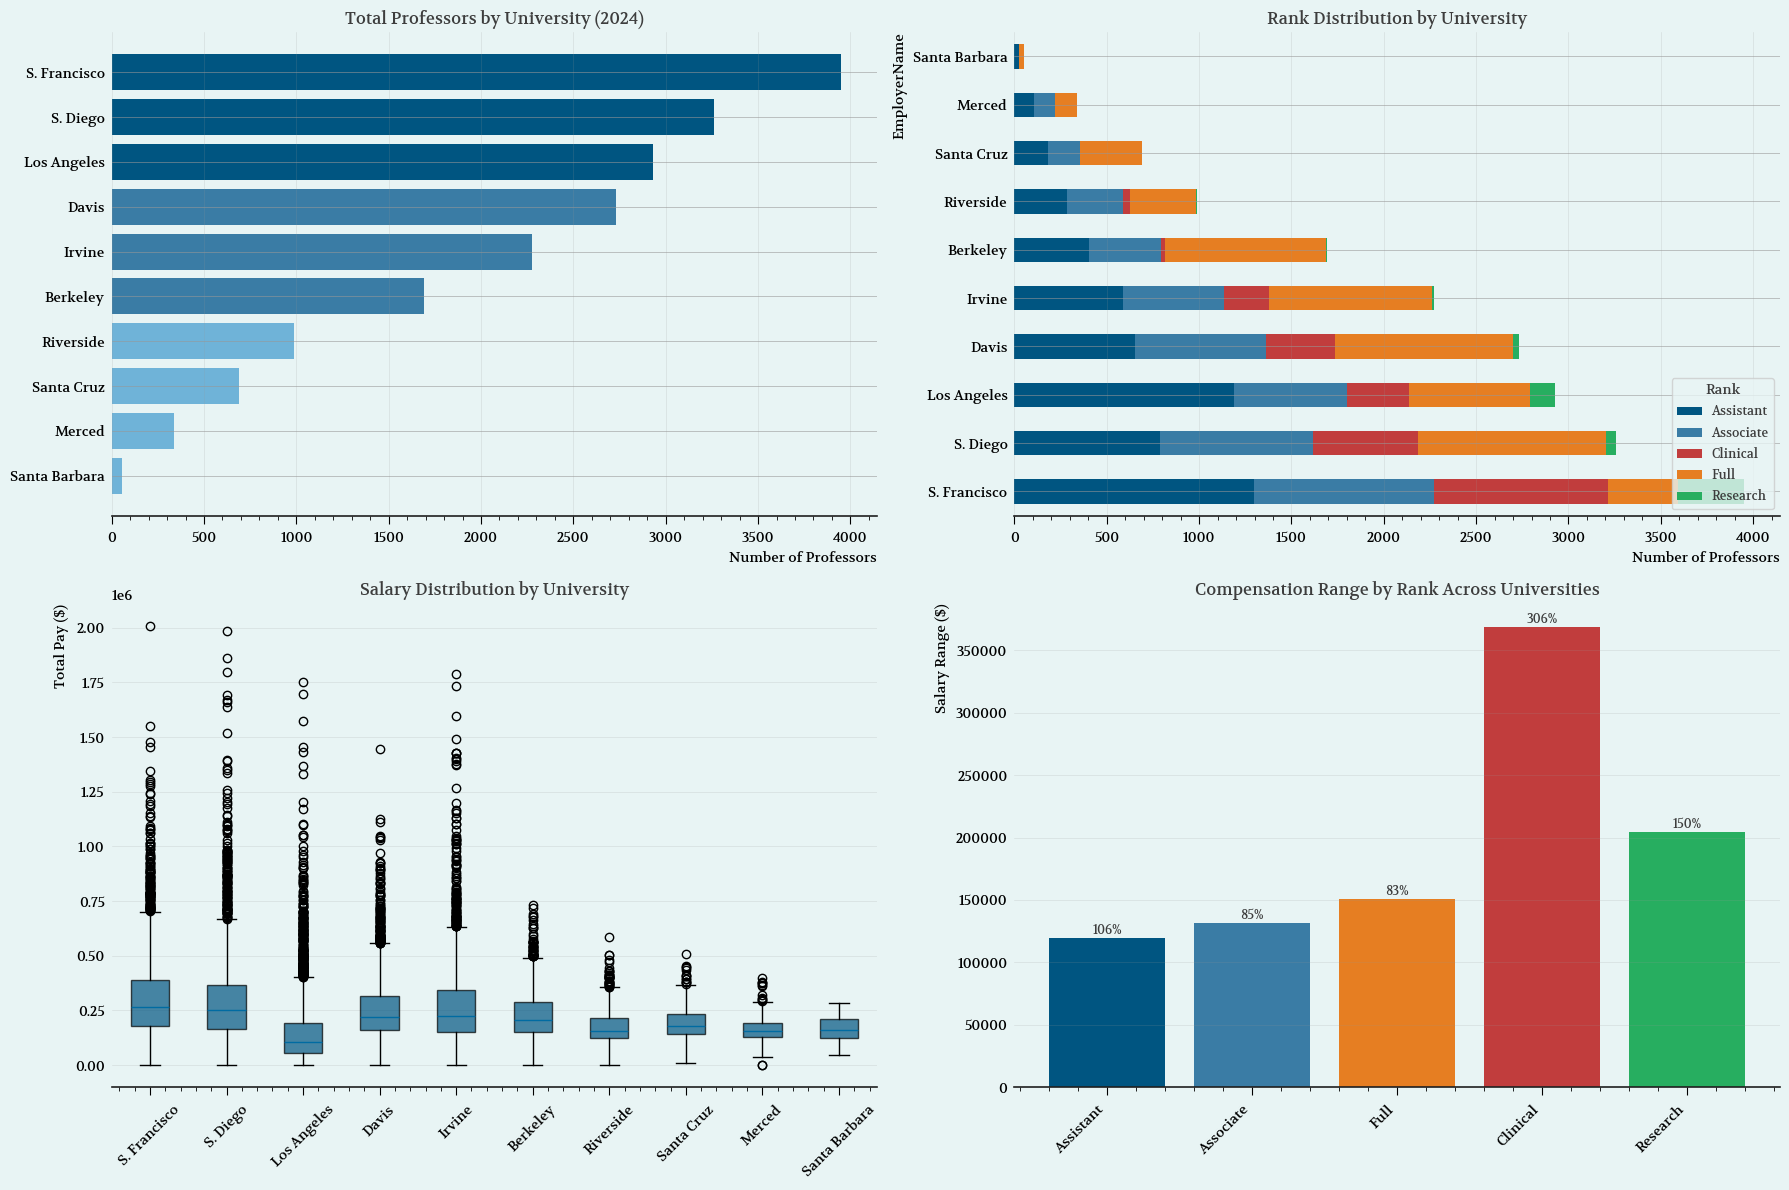

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Professor Count by University
ax1 = axes[0, 0]
colors_univ = ['#005581' if i < 3 else '#3a7ca5' if i < 6 else '#6fb3d8' for i in range(len(univ_counts))]
ax1.barh(range(len(univ_counts)), univ_counts['TotalProfessors'], color=colors_univ)
ax1.set_yticks(range(len(univ_counts)))
ax1.set_yticklabels([name.replace('University of California, ', '').replace('San ', 'S. ') for name in univ_counts['EmployerName']], fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Number of Professors')
ax1.set_title('Total Professors by University (2024)', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Rank Distribution by University (Stacked Bar)
ax2 = axes[0, 1]
rank_colors = {'Assistant': '#005581', 'Associate': '#3a7ca5', 'Full': '#e67e22', 'Clinical': '#c13d3d', 'Research': '#27ae60'}
rank_by_univ_sorted = rank_by_univ.loc[univ_counts['EmployerName']]
rank_by_univ_sorted.plot(kind='barh', stacked=True, ax=ax2, color=[rank_colors.get(rank, '#999') for rank in rank_by_univ_sorted.columns])
ax2.set_xlabel('Number of Professors')
ax2.set_title('Rank Distribution by University', fontweight='bold')
ax2.set_yticklabels([name.replace('University of California, ', '').replace('San ', 'S. ') for name in rank_by_univ_sorted.index], fontsize=10)
ax2.legend(title='Rank', loc='lower right', fontsize=9)
ax2.grid(axis='x', alpha=0.3)

# 3. Salary Range by University (Box plot)
ax3 = axes[1, 0]
box_data = [prof_2024[prof_2024['EmployerName'] == univ]['TotalPay'].values for univ in univ_counts['EmployerName']]
bp = ax3.boxplot(box_data, labels=[name.replace('University of California, ', '').replace('San ', 'S. ') for name in univ_counts['EmployerName']], vert=True, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#005581')
    patch.set_alpha(0.7)
ax3.set_ylabel('Total Pay ($)')
ax3.set_title('Salary Distribution by University', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# 4. Compensation Range by Rank (showing variation across universities)
ax4 = axes[1, 1]
rank_order = ['Assistant', 'Associate', 'Full', 'Clinical', 'Research']
x_pos = np.arange(len(rank_order))
ranges = [rank_ranges.loc[rank, 'Range'] if rank in rank_ranges.index else 0 for rank in rank_order]
range_pcts = [rank_ranges.loc[rank, 'Range %'] if rank in rank_ranges.index else 0 for rank in rank_order]

bars = ax4.bar(x_pos, ranges, color=['#005581', '#3a7ca5', '#e67e22', '#c13d3d', '#27ae60'])
ax4.set_xticks(x_pos)
ax4.set_xticklabels(rank_order, rotation=45, ha='right')
ax4.set_ylabel('Salary Range ($)')
ax4.set_title('Compensation Range by Rank Across Universities', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i, (bar, pct) in enumerate(zip(bars, range_pcts)):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.0f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

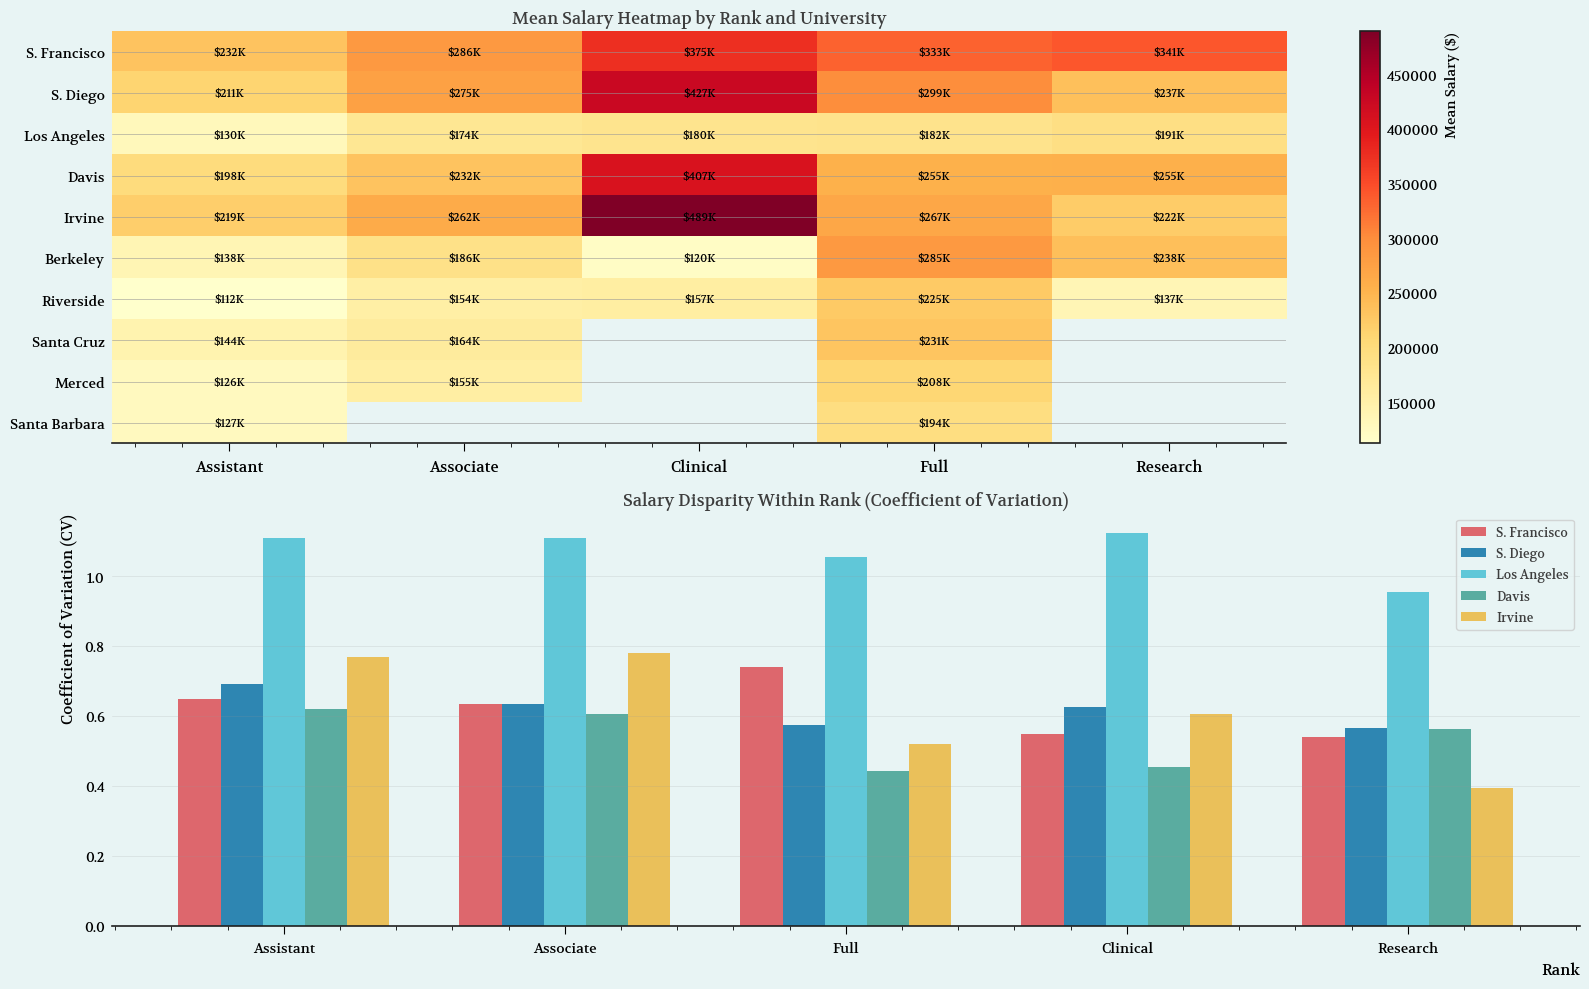

In [14]:
# Salary heatmap by rank across universities
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. Mean salary by rank and university (heatmap)
ax1 = axes[0]
salary_heatmap = prof_2024.pivot_table(values='TotalPay', index='EmployerName', columns='Rank', aggfunc='mean')
salary_heatmap = salary_heatmap.loc[univ_counts['EmployerName']]  # Sort by university size
im = ax1.imshow(salary_heatmap.values, cmap='YlOrRd', aspect='auto')
ax1.set_xticks(range(len(salary_heatmap.columns)))
ax1.set_yticks(range(len(salary_heatmap.index)))
ax1.set_xticklabels(salary_heatmap.columns, fontsize=11)
ax1.set_yticklabels([name.replace('University of California, ', '').replace('San ', 'S. ') for name in salary_heatmap.index], fontsize=10)
ax1.set_title('Mean Salary Heatmap by Rank and University', fontweight='bold', fontsize=12)

# Add colorbar
cbar = plt.colorbar(im, ax=ax1)
cbar.set_label('Mean Salary ($)', fontsize=10)

# Add salary values in cells
for i in range(len(salary_heatmap.index)):
    for j in range(len(salary_heatmap.columns)):
        val = salary_heatmap.values[i, j]
        if not np.isnan(val):
            text_color = 'white' if val > salary_heatmap.values.mean() else 'black'
            ax1.text(j, i, f'${val/1000:.0f}K', ha='center', va='center', color=text_color, fontsize=8, fontweight='bold')

# 2. Coefficient of Variation (salary disparity within rank by university)
ax2 = axes[1]
cv_by_rank_univ = prof_2024.groupby(['Rank', 'EmployerName'])['TotalPay'].apply(lambda x: x.std() / x.mean()).unstack()
cv_by_rank_univ = cv_by_rank_univ.loc[:, univ_counts['EmployerName']]

x_pos = np.arange(len(cv_by_rank_univ.index))
width = 0.15
rank_order_sorted = ['Assistant', 'Associate', 'Full', 'Clinical', 'Research']
colors_cv = ['#005581', '#3a7ca5', '#e67e22', '#c13d3d', '#27ae60']

for i, univ in enumerate(cv_by_rank_univ.columns):
    if i < 5:  # Plot top 5 universities only for clarity
        cv_values = [cv_by_rank_univ.loc[rank, univ] if rank in cv_by_rank_univ.index else 0 for rank in rank_order_sorted]
        ax2.bar(x_pos + i*width, cv_values, width, label=univ.replace('University of California, ', '').replace('San ', 'S. '), alpha=0.8)

ax2.set_xlabel('Rank', fontsize=11)
ax2.set_ylabel('Coefficient of Variation (CV)', fontsize=11)
ax2.set_title('Salary Disparity Within Rank (Coefficient of Variation)', fontweight='bold', fontsize=12)
ax2.set_xticks(x_pos + width * 2)
ax2.set_xticklabels(rank_order_sorted, fontsize=10)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

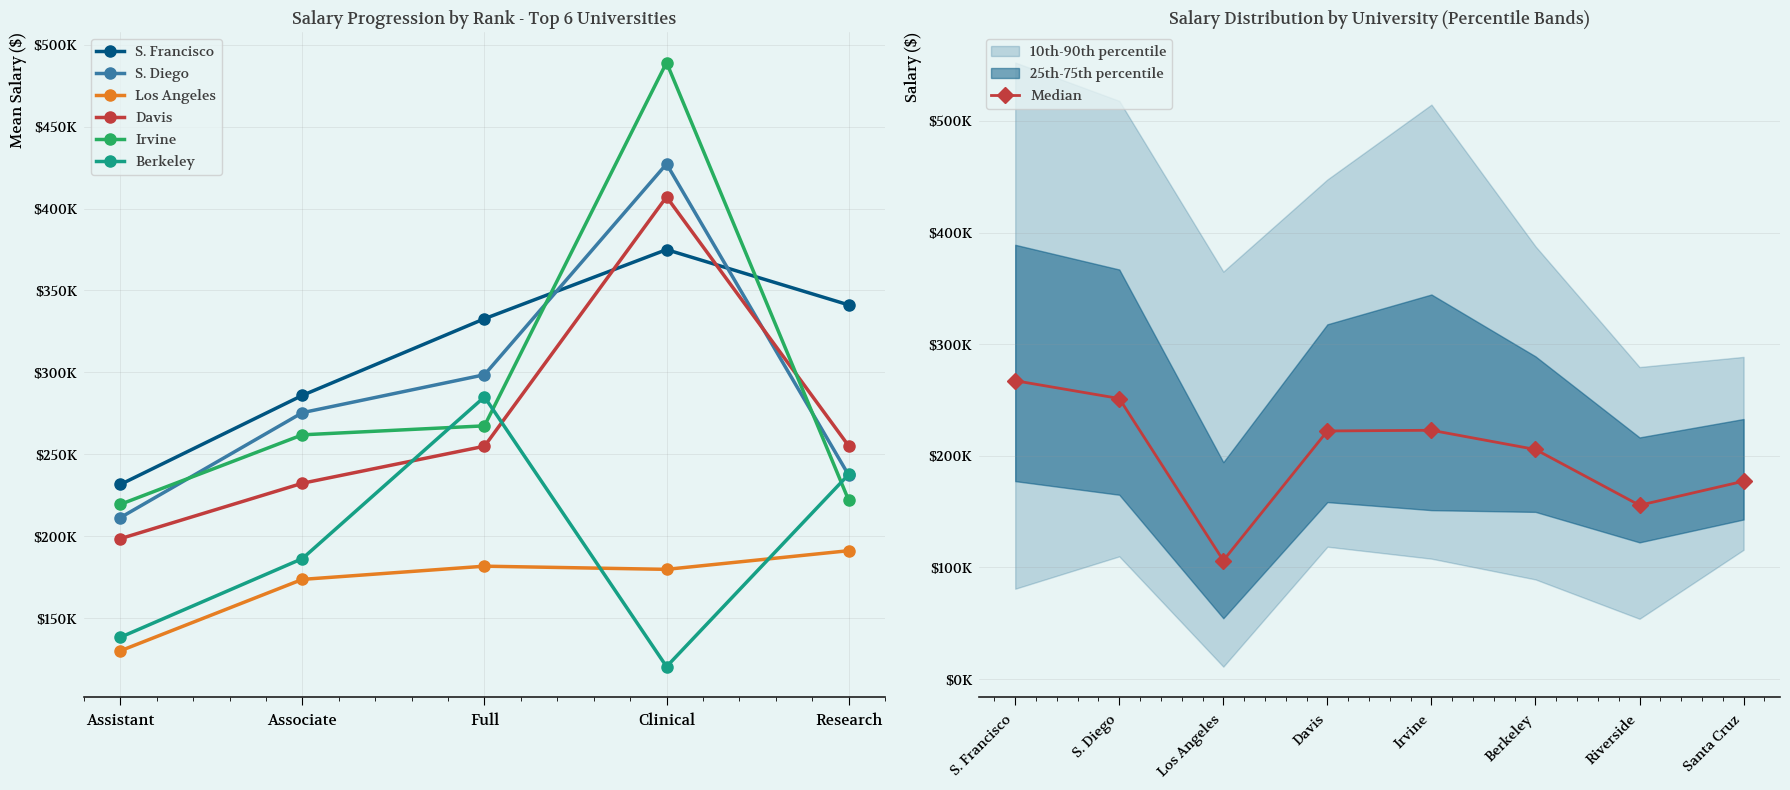

In [15]:
# Distribution comparison: median vs mean salary by university and rank
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Mean salary progression by rank across top universities
ax1 = axes[0]
rank_order_sorted = ['Assistant', 'Associate', 'Full', 'Clinical', 'Research']
top_univs = univ_counts['EmployerName'].head(6)
colors_line = ['#005581', '#3a7ca5', '#e67e22', '#c13d3d', '#27ae60', '#16a085']

for idx, univ in enumerate(top_univs):
    univ_data = prof_2024[prof_2024['EmployerName'] == univ]
    means = [univ_data[univ_data['Rank'] == rank]['TotalPay'].mean() if rank in univ_data['Rank'].values else None for rank in rank_order_sorted]
    ax1.plot(range(len(rank_order_sorted)), means, marker='o', linewidth=2.5, markersize=8, label=univ.replace('University of California, ', '').replace('San ', 'S. '), color=colors_line[idx])

ax1.set_xticks(range(len(rank_order_sorted)))
ax1.set_xticklabels(rank_order_sorted, fontsize=11)
ax1.set_ylabel('Mean Salary ($)', fontsize=11)
ax1.set_title('Salary Progression by Rank - Top 6 Universities', fontweight='bold', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# 2. Salary percentile bands by university (quartiles)
ax2 = axes[1]
univs_to_plot = univ_counts['EmployerName'].head(8)
univ_labels = [name.replace('University of California, ', '').replace('San ', 'S. ') for name in univs_to_plot]

percentiles_data = []
for univ in univs_to_plot:
    univ_data = prof_2024[prof_2024['EmployerName'] == univ]['TotalPay']
    percentiles_data.append([
        univ_data.quantile(0.1),
        univ_data.quantile(0.25),
        univ_data.quantile(0.50),
        univ_data.quantile(0.75),
        univ_data.quantile(0.90)
    ])

percentiles_data = np.array(percentiles_data)
x_pos = np.arange(len(univs_to_plot))

# Create violin-like visualization using percentile bands
ax2.fill_between(x_pos - 0.3, percentiles_data[:, 0], percentiles_data[:, 4], alpha=0.2, color='#005581', label='10th-90th percentile')
ax2.fill_between(x_pos - 0.3, percentiles_data[:, 1], percentiles_data[:, 3], alpha=0.5, color='#005581', label='25th-75th percentile')
ax2.plot(x_pos - 0.3, percentiles_data[:, 2], marker='D', color='#c13d3d', linewidth=2, markersize=8, label='Median')

ax2.set_xticks(x_pos - 0.3)
ax2.set_xticklabels(univ_labels, rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Salary ($)', fontsize=11)
ax2.set_title('Salary Distribution by University (Percentile Bands)', fontweight='bold', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# Analysis: 2024 Snapshot
Focused analysis on the 2024 professor subset.

In [16]:
# Create subset with positions that have "Prof " (with space) or "Prof-" to exclude "Professional"
prof_subset_24 = df24[df24['Position'].str.contains(r'Prof[\s\-]', case=False, na=False, regex=True)]

PROFESSOR SALARY ANALYSIS - 2024 DATA

Using column: 'TotalWages'
Total professors: 18898
Non-zero TotalWages records: 18898

1. SALARY STATISTICS
----------------------------------------------------------------------
count    1.889800e+04
mean     2.472760e+05
std      1.798689e+05
min      2.900000e+01
25%      1.341338e+05
50%      2.086905e+05
75%      3.198462e+05
max      2.009134e+06
Name: TotalWages, dtype: float64

2. SALARY BY POSITION TYPE (Top 15)
----------------------------------------------------------------------
                               count           mean    median     min      max
Position                                                                      
Prof Of Clin-Hcomp               833  448421.887155  414648.0    1875  1983544
Associate Prof Of Clin-Hcomp     147  424830.428571  388841.0    5610  1735259
Associatec Prof Of Clin-Hcomp    217  401425.133641  365721.0     262  1476706
Act Prof-Ay-1/9                    1  362951.000000  362951.0  362951 

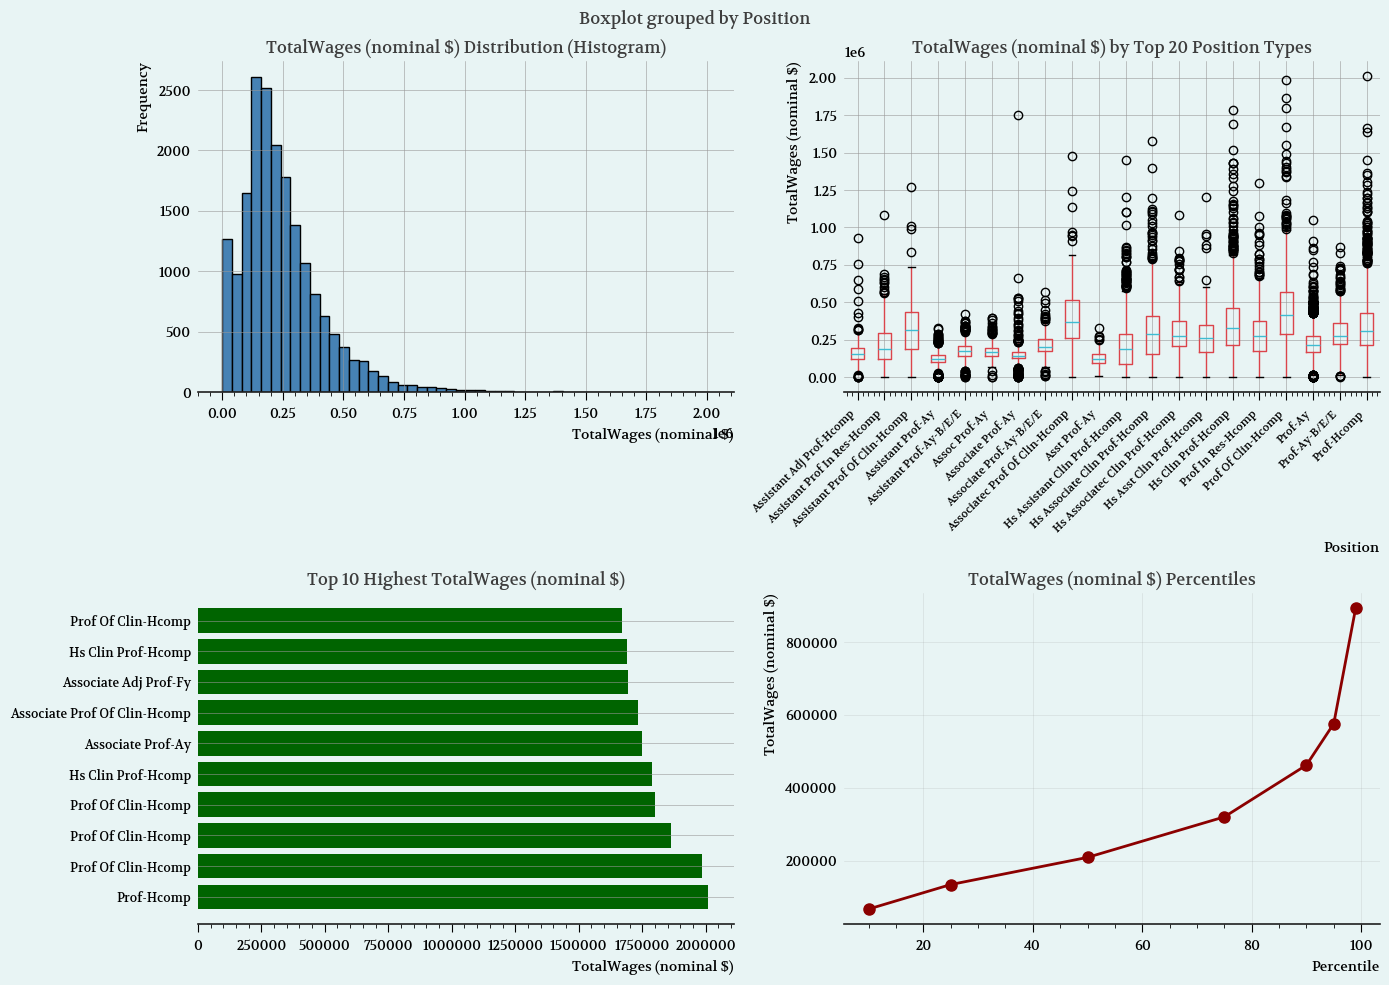

In [17]:
# Salary Analysis for Professor Positions in 2024
print("=" * 70)
print("PROFESSOR SALARY ANALYSIS - 2024 DATA")
print("=" * 70)

print(f"\nUsing column: '{salary_col}'")
print(f"Total professors: {len(prof_subset_24)}")
print(f"Non-zero {pay_col} records: {(prof_subset_24[pay_col] > 0).sum()}")

print("\n1. SALARY STATISTICS")
print("-" * 70)
print(prof_subset_24[salary_col].describe())

# Group by position type
print("\n2. SALARY BY POSITION TYPE (Top 15)")
print("-" * 70)
position_stats = prof_subset_24.groupby('Position')[salary_col].agg(['count', 'mean', 'median', 'min', 'max'])
position_stats = position_stats.sort_values('mean', ascending=False)
print(position_stats.head(15))

# Check for salary by campus/organization
print(f"\n3. SALARY BY EMPLOYER")
print("-" * 70)
org_stats = prof_subset_24.groupby('EmployerName')[salary_col].agg(['count', 'mean', 'median'])
org_stats = org_stats.sort_values('mean', ascending=False)
print(org_stats.head(10))

# Visualize salary distribution
print("\n4. SALARY DISTRIBUTION VISUALIZATION")
print("-" * 70)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
prof_subset_24[salary_col].hist(bins=50, ax=axes[0, 0], edgecolor='black', color='steelblue')
axes[0, 0].set_title(f'{salary_label} Distribution (Histogram)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel(salary_label)
axes[0, 0].set_ylabel('Frequency')

# Box plot by top 20 positions
top_positions = prof_subset_24['Position'].value_counts().head(20).index
prof_subset_top = prof_subset_24[prof_subset_24['Position'].isin(top_positions)]
prof_subset_top.boxplot(column=salary_col, by='Position', ax=axes[0, 1])
axes[0, 1].set_title(f'{salary_label} by Top 20 Position Types', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Position')
axes[0, 1].set_ylabel(salary_label)
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

# Top 10 highest paid
top_10 = prof_subset_24.nlargest(10, salary_col)[[salary_col, 'Position', 'EmployerName']]
axes[1, 0].barh(range(len(top_10)), top_10[salary_col].values, color='darkgreen')
axes[1, 0].set_yticks(range(len(top_10)))
axes[1, 0].set_yticklabels([f"{pos[:30]}" for pos in top_10['Position'].values], fontsize=9)
axes[1, 0].set_title(f'Top 10 Highest {salary_label}', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel(salary_label)
axes[1, 0].ticklabel_format(style='plain', axis='x')

# Salary percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
percentile_values = [np.percentile(prof_subset_24[salary_col].dropna(), p) for p in percentiles]
axes[1, 1].plot(percentiles, percentile_values, marker='o', linewidth=2, markersize=8, color='darkred')
axes[1, 1].set_title(f'{salary_label} Percentiles', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Percentile')
axes[1, 1].set_ylabel(salary_label)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# Multi-Year Analysis
Professor salary trends across 2012–2024 (nominal wages).

In [18]:
# Collect professor salary data across all years (2012-2024)
print("=" * 70)
print("PROFESSOR SALARY TRENDS ACROSS ALL YEARS (2012-2024)")
print("=" * 70)

prof_subsets = {}
years = list(range(12, 25))  # 12-24 for 2012-2024

for year in years:
    df_name = f'df{year:02d}'
    if df_name in globals():
        df = globals()[df_name]
        prof_subset = df[df['Position'].str.contains(r'Prof[\s\-]', case=False, na=False, regex=True)]
        prof_subsets[f'20{year}'] = prof_subset
        print(f"{df_name} -> 20{year}: {len(prof_subset)} professors")

print("\n" + "=" * 70)
print("YEAR-BY-YEAR STATISTICS")
print("=" * 70)

yearly_stats = []
for year_str in sorted(prof_subsets.keys()):
    df_prof = prof_subsets[year_str]
    stats = {
        'Year': year_str,
        'Count': len(df_prof),
        'Mean': df_prof[salary_col].mean(),
        'Median': df_prof[salary_col].median(),
        'Std': df_prof[salary_col].std(),
        'Min': df_prof[salary_col].min(),
        'Max': df_prof[salary_col].max(),
        'Q25': df_prof[salary_col].quantile(0.25),
        'Q75': df_prof[salary_col].quantile(0.75),
    }
    yearly_stats.append(stats)

yearly_df = pd.DataFrame(yearly_stats)
print(yearly_df.to_string(index=False))

print("\n" + "=" * 70)
print("YEAR-OVER-YEAR CHANGE IN MEAN SALARY")
print("=" * 70)
yearly_df['YoY_Change'] = yearly_df['Mean'].diff()
yearly_df['YoY_Change_Pct'] = yearly_df['Mean'].pct_change() * 100
print(yearly_df[['Year', 'Mean', 'YoY_Change', 'YoY_Change_Pct']].to_string(index=False))

print("\n" + "=" * 70)
print("PRE-2022 vs POST-2022 COMPARISON")
print("=" * 70)

pre_df = yearly_df[yearly_df['Year'].astype(int) < 2022]
post_df = yearly_df[yearly_df['Year'].astype(int) >= 2022]

pre_mean = pre_df['Mean'].mean()
post_mean = post_df['Mean'].mean()
level_change = post_mean - pre_mean
pct_change = (level_change / pre_mean) * 100 if pre_mean > 0 else np.nan

print(f"Pre-2022 average mean salary (2012-2021): ${pre_mean:,.2f}")
print(f"Post-2022 average mean salary (2022-2024): ${post_mean:,.2f}")
print(f"Post-2022 minus pre-2022: ${level_change:,.2f} ({pct_change:+.2f}%)")

PROFESSOR SALARY TRENDS ACROSS ALL YEARS (2012-2024)
df12 -> 2012: 16017 professors
df13 -> 2013: 15711 professors
df14 -> 2014: 16042 professors
df15 -> 2015: 16508 professors
df16 -> 2016: 17176 professors
df17 -> 2017: 17739 professors
df18 -> 2018: 18151 professors
df19 -> 2019: 17963 professors
df20 -> 2020: 19224 professors
df21 -> 2021: 19415 professors
df22 -> 2022: 19737 professors
df23 -> 2023: 20176 professors
df24 -> 2024: 18898 professors

YEAR-BY-YEAR STATISTICS
Year  Count          Mean    Median           Std   Min       Max       Q25       Q75
2012  16017 162635.753743 138400.02 117478.215636  50.0 2232151.1  92418.35 207400.02
2013  15711 172837.703265 146505.00 122877.238236 100.0 2232184.0  98498.50 217442.00
2014  16042 179201.553360 152000.00 128029.802252   1.0 2303327.0 101381.75 225693.75
2015  16508 187178.110976 158688.00 133957.295889  16.0 2335746.0 105573.00 236042.00
2016  17176 195354.620168 165120.50 142232.674708   8.0 2482207.0 109265.00 247016.50
201

# Visualization: Trends
Year-by-year trend charts for professor compensation.


SALARY TREND VISUALIZATION (2012-2024, nominal)


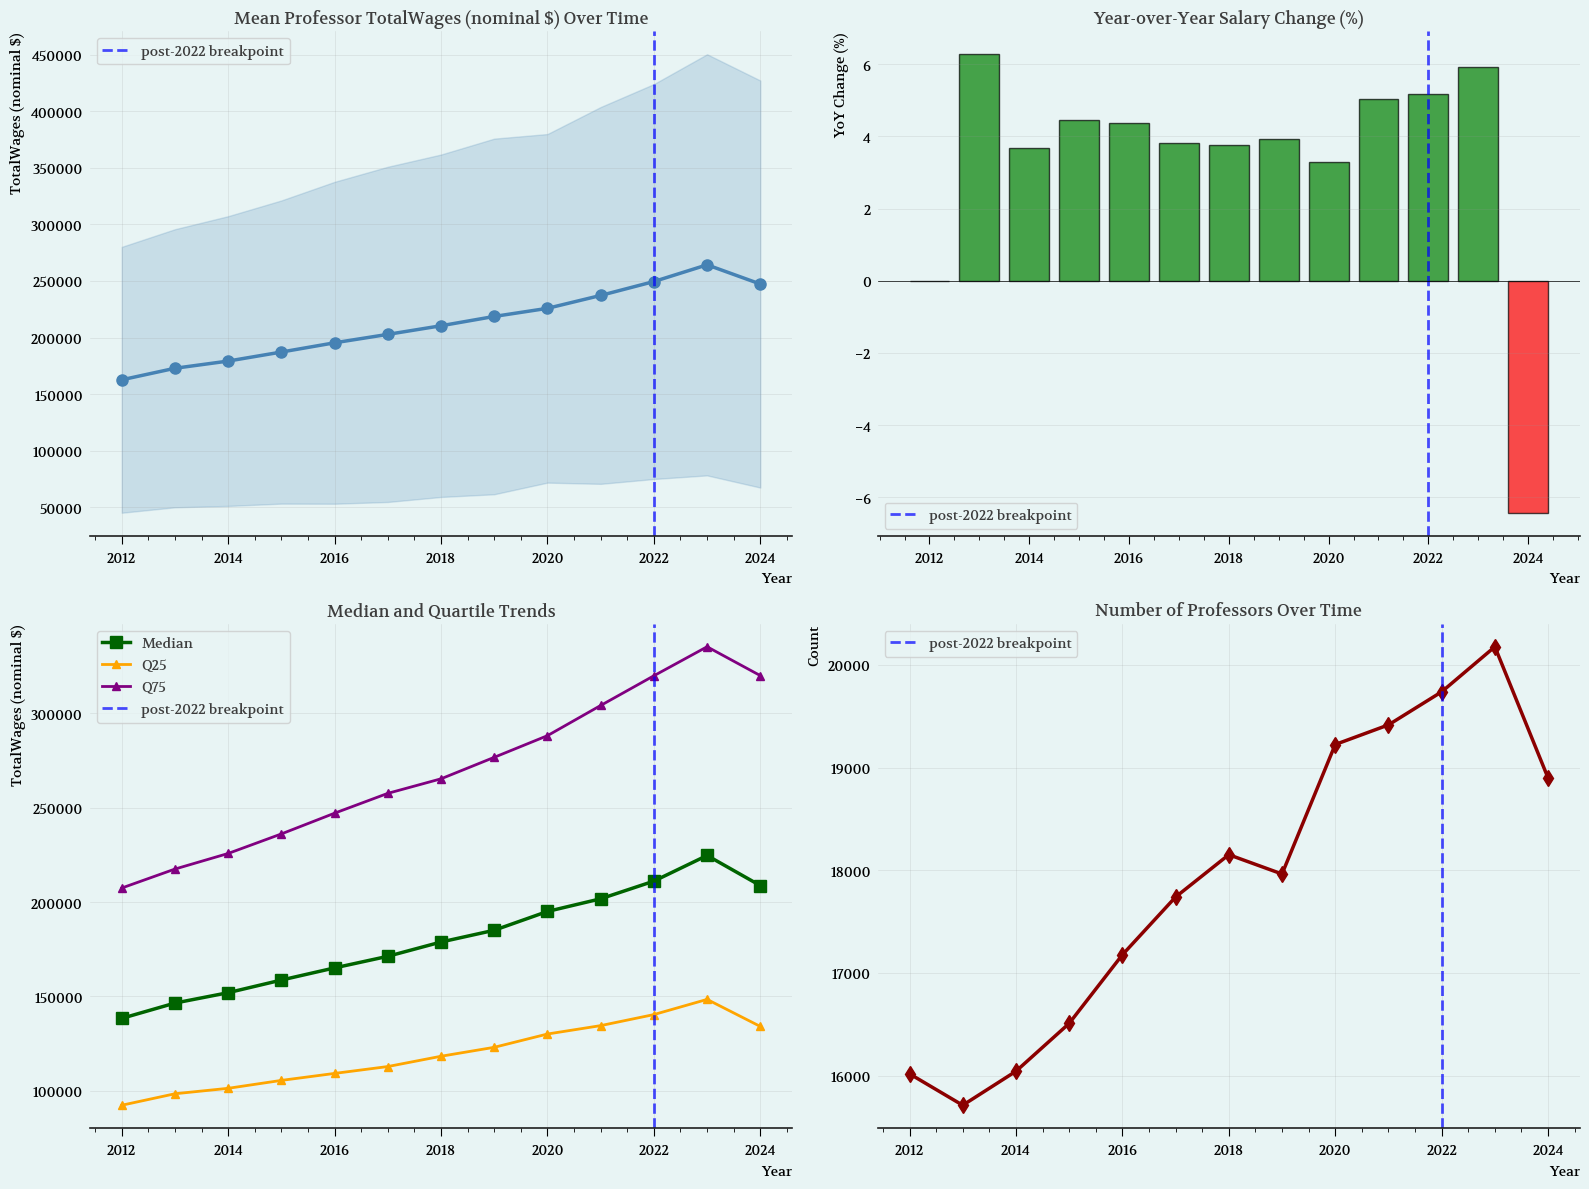


✓ Visualizations complete!


In [19]:
# Visualize salary trends across years
print("\n" + "=" * 70)
print("SALARY TREND VISUALIZATION (2012-2024, nominal)")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

years_list = yearly_df['Year'].tolist()
years_numeric = [int(y) for y in years_list]

# 1. Mean salary trend
axes[0, 0].plot(years_numeric, yearly_df['Mean'], marker='o', linewidth=2.5, markersize=8, color='steelblue')
axes[0, 0].axvline(x=2022, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='post-2022 breakpoint')
axes[0, 0].fill_between(years_numeric, yearly_df['Mean'] - yearly_df['Std'], yearly_df['Mean'] + yearly_df['Std'], alpha=0.2, color='steelblue')
axes[0, 0].set_title(f'Mean Professor {salary_label} Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel(salary_label)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].ticklabel_format(style='plain', axis='y')

# 2. Year-over-year percentage change
yoy_change_pct = yearly_df['YoY_Change_Pct'].fillna(0)
colors = ['green' if x > 0 else 'red' for x in yoy_change_pct]
axes[0, 1].bar(years_numeric, yoy_change_pct, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=2022, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='post-2022 breakpoint')
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].set_title('Year-over-Year Salary Change (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('YoY Change (%)')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].legend()

# 3. Median + Quartiles
axes[1, 0].plot(years_numeric, yearly_df['Median'], marker='s', linewidth=2.5, markersize=8, color='darkgreen', label='Median')
axes[1, 0].plot(years_numeric, yearly_df['Q25'], marker='^', linewidth=2, markersize=6, color='orange', label='Q25')
axes[1, 0].plot(years_numeric, yearly_df['Q75'], marker='^', linewidth=2, markersize=6, color='purple', label='Q75')
axes[1, 0].axvline(x=2022, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='post-2022 breakpoint')
axes[1, 0].set_title('Median and Quartile Trends', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel(salary_label)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].ticklabel_format(style='plain', axis='y')

# 4. Count of professors over time
axes[1, 1].plot(years_numeric, yearly_df['Count'], marker='d', linewidth=2.5, markersize=8, color='darkred')
axes[1, 1].axvline(x=2022, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='post-2022 breakpoint')
axes[1, 1].set_title('Number of Professors Over Time', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n✓ Visualizations complete!")

# Analysis: Rank Variation
Variation and dispersion metrics by professor rank.

In [20]:
# Categorize professor ranks based on title

def categorize_rank_variation(position):
    pos_lower = position.lower()
    if 'assistant' in pos_lower or 'asst' in pos_lower:
        return 'Assistant'
    elif 'associate' in pos_lower or 'assoc' in pos_lower:
        return 'Associate'
    elif 'clinical' in pos_lower or 'clin' in pos_lower:
        return 'Clinical'
    elif 'research' in pos_lower or 'res' in pos_lower:
        return 'Research'
    return 'Full'


for year_str in prof_subsets.keys():
    prof_subsets[year_str]['Rank'] = prof_subsets[year_str]['Position'].apply(categorize_rank_variation)

print("=" * 80)
print("SALARY VARIATION WITHIN PROFESSOR RANKS BY YEAR (2012-2024)")
print("=" * 80)

variation_analysis = []

for year_str in sorted(prof_subsets.keys()):
    df_year = prof_subsets[year_str]
    year_int = int(year_str)

    for rank in ['Assistant', 'Associate', 'Full', 'Clinical', 'Research']:
        rank_data = df_year[df_year['Rank'] == rank][salary_col]

        if len(rank_data) > 0:
            mean_sal = rank_data.mean()
            std_sal = rank_data.std()
            cv = (std_sal / mean_sal * 100) if mean_sal > 0 else 0
            min_sal = rank_data.min()
            max_sal = rank_data.max()
            range_sal = max_sal - min_sal
            q25 = rank_data.quantile(0.25)
            q75 = rank_data.quantile(0.75)
            iqr = q75 - q25
            count = len(rank_data)

            variation_analysis.append({
                'Year': year_int,
                'Rank': rank,
                'Count': count,
                'Mean': mean_sal,
                'Std': std_sal,
                'CV%': cv,
                'Min': min_sal,
                'Max': max_sal,
                'Range': range_sal,
                'Q25': q25,
                'Q75': q75,
                'IQR': iqr,
            })

variation_df = pd.DataFrame(variation_analysis)

for rank in ['Assistant', 'Associate', 'Full', 'Clinical', 'Research']:
    rank_data = variation_df[variation_df['Rank'] == rank]
    if len(rank_data) > 0:
        print(f"\n{rank.upper()} PROFESSORS")
        print("-" * 80)
        print(rank_data[['Year', 'Count', 'Mean', 'Std', 'CV%', 'IQR']].to_string(index=False))

        pre_cv = rank_data[rank_data['Year'] < 2022]['CV%'].mean()
        post_cv = rank_data[rank_data['Year'] >= 2022]['CV%'].mean()
        cv_change_pct = ((post_cv - pre_cv) / pre_cv * 100) if pre_cv > 0 else np.nan

        print(f"\n  Avg CV (2012-2021): {pre_cv:.2f}%")
        print(f"  Avg CV (2022-2024): {post_cv:.2f}%")
        print(f"  CV Change (post-2022 vs pre-2022): {cv_change_pct:+.2f}%")

SALARY VARIATION WITHIN PROFESSOR RANKS BY YEAR (2012-2024)

ASSISTANT PROFESSORS
--------------------------------------------------------------------------------
 Year  Count          Mean           Std       CV%       IQR
 2012   3945 123857.292537  92701.724395 74.845592  94262.48
 2013   4166 134787.926308  99955.358118 74.157501 100775.00
 2014   4078 136396.194949 103607.945301 75.961023 107411.00
 2015   4333 142257.807985 106554.023686 74.902056 112836.00
 2016   4744 147528.612352 113119.161456 76.676083 118434.50
 2017   5070 153735.880868 116182.061326 75.572508 122998.00
 2018   5321 158610.412141 119699.990417 75.467927 124581.00
 2019   5607 170369.088639 125085.247855 73.420154 129377.50
 2020   6045 175811.418693 121989.368878 69.386488 132404.00
 2021   5540 187507.477617 133057.906223 70.961387 146316.75
 2022   5500 195224.943091 144899.707135 74.221923 154665.50
 2023   5536 206170.454841 155309.027638 75.330400 164542.50
 2024   5514 183208.623685 143030.399523 78.

# Visualization: Rank Variation
Visual trends in variation metrics by rank.


VISUALIZATION: SALARY VARIATION TRENDS BY RANK (2012-2024)


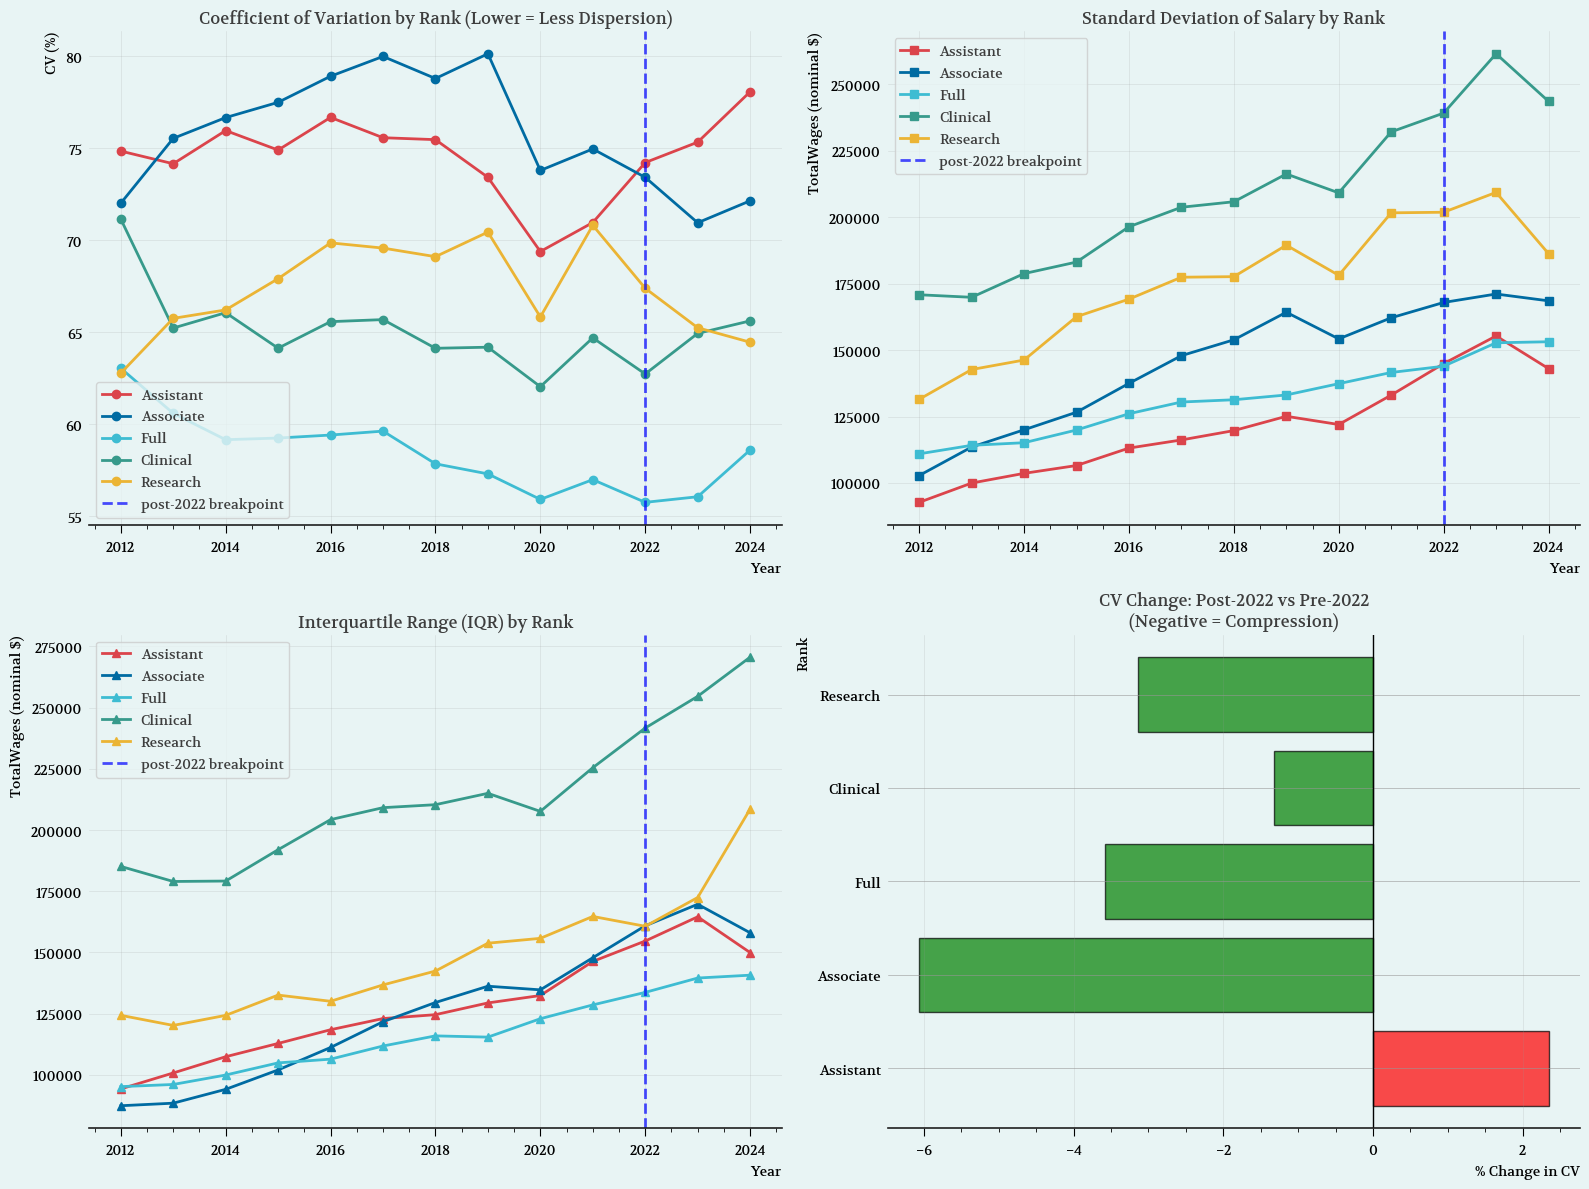

In [21]:
# Visualize salary variation trends by rank
print("\n" + "=" * 80)
print("VISUALIZATION: SALARY VARIATION TRENDS BY RANK (2012-2024)")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Coefficient of Variation (CV) over time by rank
for rank in ['Assistant', 'Associate', 'Full', 'Clinical', 'Research']:
    rank_data = variation_df[variation_df['Rank'] == rank].sort_values('Year')
    if len(rank_data) > 0:
        axes[0, 0].plot(rank_data['Year'], rank_data['CV%'], marker='o', label=rank, linewidth=2)

axes[0, 0].axvline(x=2022, color='blue', linestyle='--', alpha=0.7, linewidth=2, label='post-2022 breakpoint')
axes[0, 0].set_title('Coefficient of Variation by Rank (Lower = Less Dispersion)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('CV (%)')
axes[0, 0].legend(loc='best')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Standard Deviation over time by rank
for rank in ['Assistant', 'Associate', 'Full', 'Clinical', 'Research']:
    rank_data = variation_df[variation_df['Rank'] == rank].sort_values('Year')
    if len(rank_data) > 0:
        axes[0, 1].plot(rank_data['Year'], rank_data['Std'], marker='s', label=rank, linewidth=2)

axes[0, 1].axvline(x=2022, color='blue', linestyle='--', alpha=0.7, linewidth=2, label='post-2022 breakpoint')
axes[0, 1].set_title('Standard Deviation of Salary by Rank', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel(salary_label)
axes[0, 1].legend(loc='best')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].ticklabel_format(style='plain', axis='y')

# Plot 3: Interquartile Range (IQR) over time by rank
for rank in ['Assistant', 'Associate', 'Full', 'Clinical', 'Research']:
    rank_data = variation_df[variation_df['Rank'] == rank].sort_values('Year')
    if len(rank_data) > 0:
        axes[1, 0].plot(rank_data['Year'], rank_data['IQR'], marker='^', label=rank, linewidth=2)

axes[1, 0].axvline(x=2022, color='blue', linestyle='--', alpha=0.7, linewidth=2, label='post-2022 breakpoint')
axes[1, 0].set_title('Interquartile Range (IQR) by Rank', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel(salary_label)
axes[1, 0].legend(loc='best')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].ticklabel_format(style='plain', axis='y')

# Plot 4: CV change comparing pre-2022 vs post-2022
cv_change_data = []
ranks_with_data = []

for rank in ['Assistant', 'Associate', 'Full', 'Clinical', 'Research']:
    pre_cv = variation_df[(variation_df['Rank'] == rank) & (variation_df['Year'] < 2022)]['CV%'].mean()
    post_cv = variation_df[(variation_df['Rank'] == rank) & (variation_df['Year'] >= 2022)]['CV%'].mean()

    if not np.isnan(pre_cv) and not np.isnan(post_cv) and pre_cv != 0:
        change = ((post_cv - pre_cv) / pre_cv * 100)
        cv_change_data.append(change)
        ranks_with_data.append(rank)

colors = ['green' if x < 0 else 'red' for x in cv_change_data]
axes[1, 1].barh(ranks_with_data, cv_change_data, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_title('CV Change: Post-2022 vs Pre-2022\n(Negative = Compression)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('% Change in CV')
axes[1, 1].set_ylabel('Rank')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Statistical Test: Variance Shift Around 2022
Assess variance changes: pre-2022 vs post-2022.

In [22]:
# Statistical test: Levene's test for equality of variances (pre-2022 vs post-2022)
from scipy import stats

print("\n" + "=" * 80)
print("STATISTICAL TEST: LEVENE'S TEST FOR VARIANCE EQUALITY")
print("Testing if salary variation within each rank changed after 2022")
print("=" * 80)

results_levene = []

for rank in ['Assistant', 'Associate', 'Full', 'Clinical', 'Research']:
    pre_2022_data = []
    post_2022_data = []

    for year_str in sorted(prof_subsets.keys()):
        year_int = int(year_str)
        df_year = prof_subsets[year_str]
        rank_salaries = df_year[df_year['Rank'] == rank][salary_col].values

        if len(rank_salaries) > 0:
            if year_int < 2022:
                pre_2022_data.extend(rank_salaries)
            else:
                post_2022_data.extend(rank_salaries)

    if len(pre_2022_data) > 1 and len(post_2022_data) > 1:
        statistic, p_value = stats.levene(pre_2022_data, post_2022_data)

        var_pre = np.var(pre_2022_data, ddof=1)
        var_post = np.var(post_2022_data, ddof=1)
        var_ratio = var_post / var_pre

        results_levene.append({
            'Rank': rank,
            'Pre-2022 Var': var_pre,
            'Post-2022 Var': var_post,
            'Var Ratio': var_ratio,
            'Levene Stat': statistic,
            'p-value': p_value,
            'Significant (α=0.05)': 'Yes' if p_value < 0.05 else 'No',
        })

levene_df = pd.DataFrame(results_levene)
print("\n" + levene_df.to_string(index=False))

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
print("\nVariance Ratio > 1: Variance INCREASED post-2022")
print("Variance Ratio < 1: Variance DECREASED post-2022")
print("p-value < 0.05: Change in variance is STATISTICALLY SIGNIFICANT")
print("\n" + "-" * 80)

for _, row in levene_df.iterrows():
    rank = row['Rank']
    var_pre = row['Pre-2022 Var']
    var_post = row['Post-2022 Var']
    p = row['p-value']
    sig = row['Significant (α=0.05)']

    print(f"\n{rank} Professors:")
    print(f"  Variance pre-2022: ${var_pre:,.0f}")
    print(f"  Variance post-2022: ${var_post:,.0f}")
    print(f"  Levene's p-value: {p:.4f} ({'Significant' if sig == 'Yes' else 'Not Significant'})")


STATISTICAL TEST: LEVENE'S TEST FOR VARIANCE EQUALITY
Testing if salary variation within each rank changed after 2022

     Rank  Pre-2022 Var  Post-2022 Var  Var Ratio  Levene Stat       p-value Significant (α=0.05)
Assistant  1.366030e+10   2.194734e+10   1.606652   640.513928 1.233071e-140                  Yes
Associate  2.043885e+10   2.865832e+10   1.402150   373.209069  7.325330e-83                  Yes
     Full  1.655652e+10   2.247798e+10   1.357652   329.694277  1.551039e-73                  Yes
 Clinical  4.134096e+10   6.188607e+10   1.496967   192.897329  1.093521e-43                  Yes
 Research  2.907558e+10   3.996733e+10   1.374601    38.166983  6.831777e-10                  Yes

INTERPRETATION

Variance Ratio > 1: Variance INCREASED post-2022
Variance Ratio < 1: Variance DECREASED post-2022
p-value < 0.05: Change in variance is STATISTICALLY SIGNIFICANT

--------------------------------------------------------------------------------

Assistant Professors:
  Varian

# Distribution Comparison
Pre-2022 vs post-2022 salary distributions by rank (nominal wages).


DISTRIBUTION COMPARISON: PRE-2022 vs POST-2022


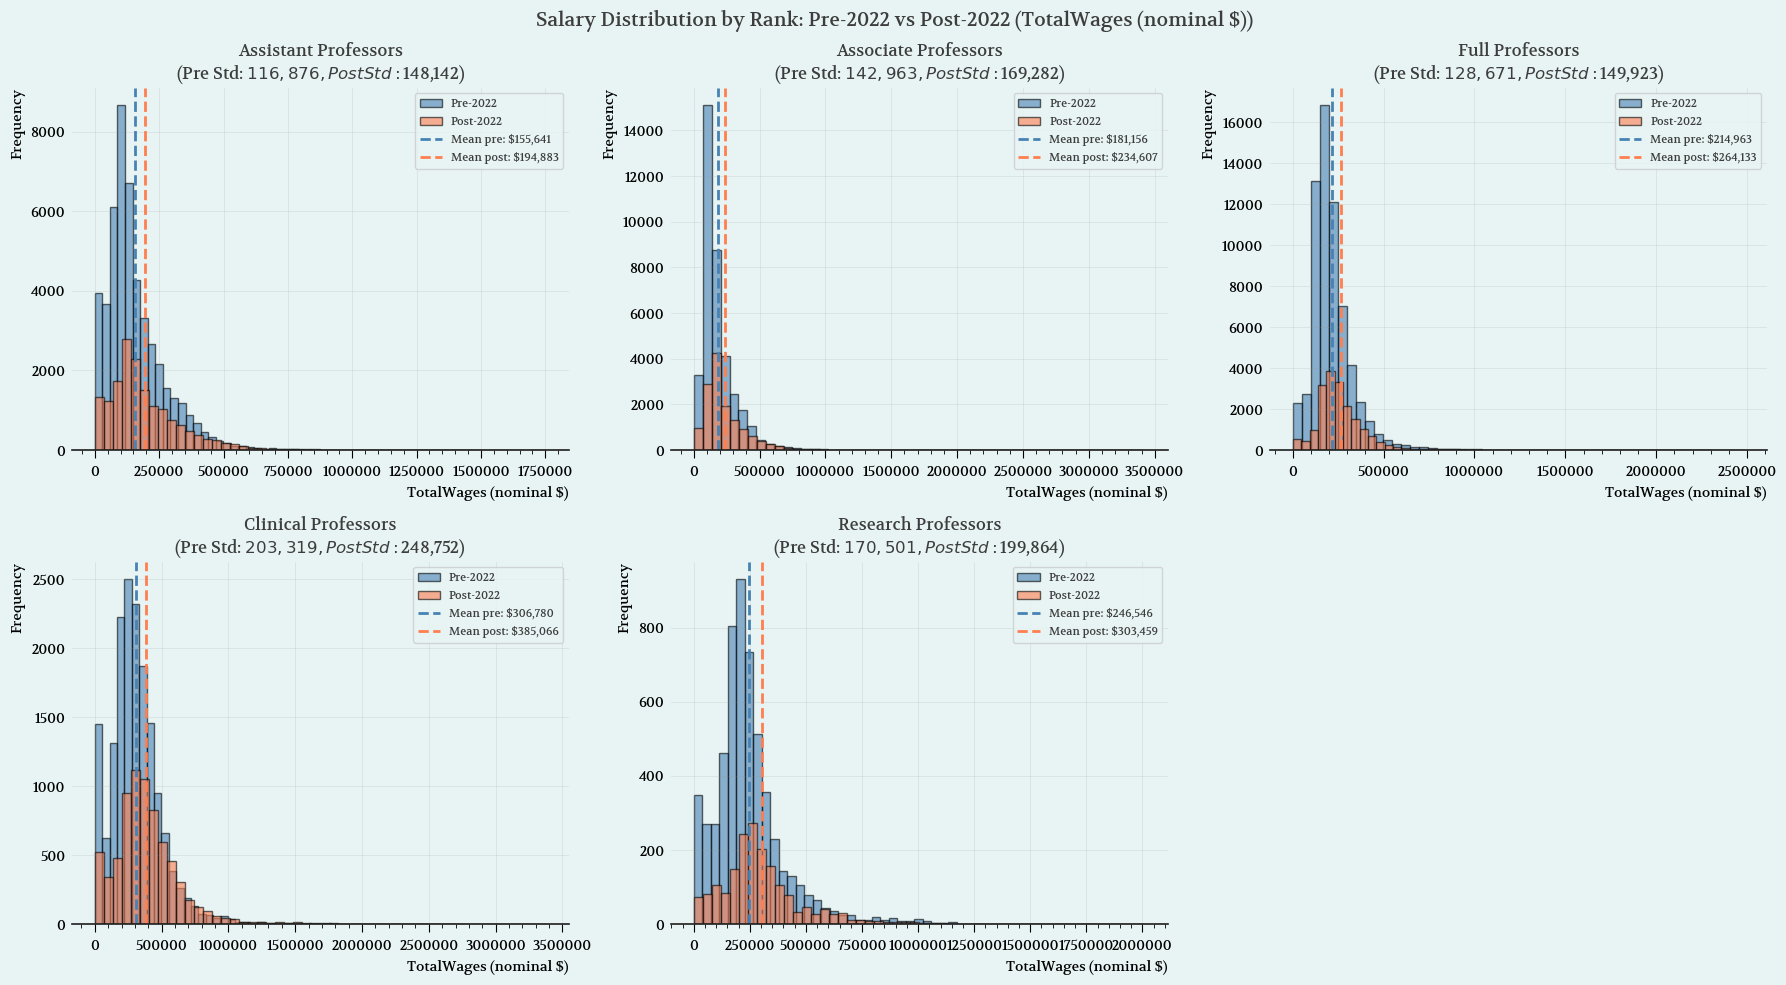


Key observations:
- Leftward shift in distribution = lower post-2022 salaries
- Narrower distribution = more uniformity within rank
- Mean changes summarize pre vs post-2022 shifts


In [23]:
# Visualize distribution comparison: pre-2022 vs post-2022
print("\n" + "=" * 80)
print("DISTRIBUTION COMPARISON: PRE-2022 vs POST-2022")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Salary Distribution by Rank: Pre-2022 vs Post-2022 ({salary_label})', fontsize=14, fontweight='bold')

ranks_to_plot = ['Assistant', 'Associate', 'Full', 'Clinical', 'Research']

for idx, rank in enumerate(ranks_to_plot):
    ax = axes.flat[idx]

    pre_2022_data = []
    post_2022_data = []

    for year_str in sorted(prof_subsets.keys()):
        year_int = int(year_str)
        df_year = prof_subsets[year_str]
        rank_salaries = df_year[df_year['Rank'] == rank][salary_col].values

        if len(rank_salaries) > 0:
            if year_int < 2022:
                pre_2022_data.extend(rank_salaries)
            else:
                post_2022_data.extend(rank_salaries)

    if len(pre_2022_data) > 0 and len(post_2022_data) > 0:
        ax.hist(pre_2022_data, bins=50, alpha=0.6, color='steelblue', label='Pre-2022', edgecolor='black')
        ax.hist(post_2022_data, bins=50, alpha=0.6, color='coral', label='Post-2022', edgecolor='black')

        mean_pre = np.mean(pre_2022_data)
        mean_post = np.mean(post_2022_data)
        std_pre = np.std(pre_2022_data)
        std_post = np.std(post_2022_data)

        ax.axvline(mean_pre, color='steelblue', linestyle='--', linewidth=2, label=f'Mean pre: ${mean_pre:,.0f}')
        ax.axvline(mean_post, color='coral', linestyle='--', linewidth=2, label=f'Mean post: ${mean_post:,.0f}')

        ax.set_title(f'{rank} Professors\n(Pre Std: ${std_pre:,.0f}, Post Std: ${std_post:,.0f})', fontweight='bold')
        ax.set_xlabel(salary_label)
        ax.set_ylabel('Frequency')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.ticklabel_format(style='plain', axis='x')

axes.flat[5].axis('off')

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- Leftward shift in distribution = lower post-2022 salaries")
print("- Narrower distribution = more uniformity within rank")
print("- Mean changes summarize pre vs post-2022 shifts")

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# --- 1) Locate and verify files (2012-2024, professors folder only) ---
base_dir = Path.cwd()
required_years = list(range(2012, 2025))

file_paths = []
missing_years = []
for year in required_years:
    in_professors = base_dir / "professors" / f"uc_professors_{year}.csv"
    if in_professors.exists():
        file_paths.append(in_professors)
    else:
        missing_years.append(year)

print("Professor CSV file check:")
for p in file_paths:
    print(f"  ✓ {p.relative_to(base_dir)}")
if missing_years:
    print(f"  Missing years: {missing_years}")
    raise FileNotFoundError(f"Missing required files for years: {missing_years}")

# --- 2) Load and combine data, keep only required columns ---
keep_cols = ["Year", "EmployerName", "Position", "RegularPay", "TotalWages"]
frames = []

for p in file_paths:
    df = pd.read_csv(p)
    for col in keep_cols:
        if col not in df.columns:
            df[col] = np.nan

    year_from_name = int(p.stem.split("_")[-1])
    df = df[keep_cols].copy()
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").fillna(year_from_name)
    df["Year"] = df["Year"].astype(int)
    frames.append(df)

panel = pd.concat(frames, ignore_index=True)
print(f"\nRows loaded (combined panel): {len(panel):,}")

# --- 3) Rank mapping from Position ---
position_lower = panel["Position"].fillna("").str.lower()
panel["Rank"] = np.select(
    [
        position_lower.str.contains("assistant") | position_lower.str.contains("asst"),
        position_lower.str.contains("associate") | position_lower.str.contains("assoc"),
        position_lower.str.contains("clinical") | position_lower.str.contains("clin"),
        position_lower.str.contains("research") | position_lower.str.contains("res"),
    ],
    ["Assistant", "Associate", "Clinical", "Research"],
    default="Full",
)

# --- 4) Numeric wages + logs on positive observations only ---
panel["TotalWages"] = pd.to_numeric(panel["TotalWages"], errors="coerce")
panel["RegularPay"] = pd.to_numeric(panel["RegularPay"], errors="coerce")

panel_total = panel.loc[panel["TotalWages"] > 0].copy()
panel_total["log_total_wages"] = np.log(panel_total["TotalWages"])

panel_regular = panel.loc[panel["RegularPay"] > 0].copy()
panel_regular["log_regular_pay"] = np.log(panel_regular["RegularPay"])

print(f"Rows used for log_total_wages regression: {len(panel_total):,}")
print(f"Rows used for log_regular_pay regression: {len(panel_regular):,}")

# --- 5) Transparency indicator ---
panel_total["post2022"] = (panel_total["Year"] >= 2022).astype(int)
panel_regular["post2022"] = (panel_regular["Year"] >= 2022).astype(int)

# --- 6) Baseline regression (robust SE) ---
formula_total = "log_total_wages ~ post2022 + C(Rank) + C(EmployerName) + Year"
model_total = smf.ols(formula_total, data=panel_total).fit(cov_type="HC1")

# --- 7) Robustness regression with log_regular_pay ---
formula_regular = "log_regular_pay ~ post2022 + C(Rank) + C(EmployerName) + Year"
model_regular = smf.ols(formula_regular, data=panel_regular).fit(cov_type="HC1")

# --- 8) Clean regression tables (printed in notebook only) ---
def compact_table(model):
    ci = model.conf_int()
    out = pd.DataFrame(
        {
            "coef": model.params,
            "std_err": model.bse,
            "t": model.tvalues,
            "p_value": model.pvalues,
            "ci_lower": ci[0],
            "ci_upper": ci[1],
        }
    )
    return out

print("\n" + "=" * 90)
print("Baseline regression: log_total_wages ~ post2022 + C(Rank) + C(EmployerName) + Year")
print("(HC1 robust SE; nominal wages only; sample 2012-2024)")
print("=" * 90)
print(compact_table(model_total).round(4).to_string())

print("\n" + "=" * 90)
print("Robustness regression: log_regular_pay ~ post2022 + C(Rank) + C(EmployerName) + Year")
print("(HC1 robust SE; nominal wages only; sample 2012-2024)")
print("=" * 90)
print(compact_table(model_regular).round(4).to_string())

# --- 9) Short interpretation of post2022 coefficient ---
def interpret_post2022(model, outcome_name):
    b = float(model.params["post2022"])
    se = float(model.bse["post2022"])
    p = float(model.pvalues["post2022"])
    pct_approx = b * 100

    print(f"\n{outcome_name} post2022 coefficient: {b:.4f} (robust SE: {se:.4f}, p-value: {p:.4g})")
    print(
        f"Approximate interpretation: post-2022 is associated with about {pct_approx:.2f}% change in nominal {outcome_name}, "
        "holding rank, campus, and linear year trend fixed."
    )

interpret_post2022(model_total, "log_total_wages")
interpret_post2022(model_regular, "log_regular_pay")

Professor CSV file check:
  ✓ professors\uc_professors_2012.csv
  ✓ professors\uc_professors_2013.csv
  ✓ professors\uc_professors_2014.csv
  ✓ professors\uc_professors_2015.csv
  ✓ professors\uc_professors_2016.csv
  ✓ professors\uc_professors_2017.csv
  ✓ professors\uc_professors_2018.csv
  ✓ professors\uc_professors_2019.csv
  ✓ professors\uc_professors_2020.csv
  ✓ professors\uc_professors_2021.csv
  ✓ professors\uc_professors_2022.csv
  ✓ professors\uc_professors_2023.csv
  ✓ professors\uc_professors_2024.csv

Rows loaded (combined panel): 234,117
Rows used for log_total_wages regression: 234,117
Rows used for log_regular_pay regression: 229,471

Baseline regression: log_total_wages ~ post2022 + C(Rank) + C(EmployerName) + Year
(HC1 robust SE; nominal wages only; sample 2012-2024)
                                                                         coef  std_err         t  p_value  ci_lower  ci_upper
Intercept                                                            -86.1093

## Compression Test: Rank × Post2022

In [25]:
# Compression test: do rank wage gaps shrink after 2022?
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# 1) Use the same dataframe as baseline regression (panel_total)
if 'panel_total' in globals() and isinstance(panel_total, pd.DataFrame):
    compression_df = panel_total.copy()
elif 'panel' in globals() and isinstance(panel, pd.DataFrame):
    compression_df = panel.copy()
    compression_df['TotalWages'] = pd.to_numeric(compression_df['TotalWages'], errors='coerce')
    compression_df = compression_df.loc[compression_df['TotalWages'] > 0].copy()
    if 'log_total_wages' not in compression_df.columns:
        compression_df['log_total_wages'] = np.log(compression_df['TotalWages'])
    if 'post2022' not in compression_df.columns:
        compression_df['post2022'] = (compression_df['Year'] >= 2022).astype(int)
else:
    raise ValueError('Baseline dataframe not found. Run the baseline regression section first.')

# 2) Ensure required columns are available
required_cols = ['log_total_wages', 'post2022', 'Rank', 'EmployerName', 'Year']
missing = [c for c in required_cols if c not in compression_df.columns]
if missing:
    raise ValueError(f'Missing required columns for compression test: {missing}')

# 3) Estimate interaction model with HC1 robust SE
compression_formula = 'log_total_wages ~ post2022 * C(Rank) + C(EmployerName) + Year'
compression_model = smf.ols(compression_formula, data=compression_df).fit(cov_type='HC1')

# 4) Print regression summary
print('\n' + '=' * 90)
print('Compression Test Regression: log_total_wages ~ post2022 * C(Rank) + C(EmployerName) + Year')
print('(HC1 robust standard errors)')
print('=' * 90)
print(compression_model.summary())

# 5) Print requested interaction coefficients
interaction_terms = [
    'post2022:C(Rank)[T.Associate]',
    'post2022:C(Rank)[T.Clinical]',
    'post2022:C(Rank)[T.Full]',
    'post2022:C(Rank)[T.Research]'
]

print('\n' + '=' * 90)
print('Requested interaction coefficients')
print('=' * 90)
for term in interaction_terms:
    if term in compression_model.params.index:
        coef = compression_model.params[term]
        pval = compression_model.pvalues[term]
        print(f'{term}: coef={coef:.4f}, p-value={pval:.4g}')
    else:
        print(f'{term}: not estimated (reference category or absent rank)')

# 6) Short interpretation
effects = {}
for term in interaction_terms:
    if term in compression_model.params.index:
        effects[term] = compression_model.params[term]

print('\n' + '=' * 90)
print('Interpretation')
print('=' * 90)
if effects:
    negative_terms = [k for k, v in effects.items() if v < 0]
    positive_terms = [k for k, v in effects.items() if v > 0]

    if len(negative_terms) >= len(positive_terms):
        print('Most higher-rank interaction terms are negative, suggesting relative wage declines after 2022 versus the reference rank.')
    else:
        print('Most higher-rank interaction terms are positive, suggesting no broad rank-compression after 2022 versus the reference rank.')
else:
    print('Interaction terms were not available to evaluate rank-specific post-2022 compression.')


Compression Test Regression: log_total_wages ~ post2022 * C(Rank) + C(EmployerName) + Year
(HC1 robust standard errors)
                            OLS Regression Results                            
Dep. Variable:        log_total_wages   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                 2.615e+04
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:48:48   Log-Likelihood:            -3.1642e+05
No. Observations:              234117   AIC:                         6.329e+05
Df Residuals:                  234096   BIC:                         6.331e+05
Df Model:                          20                                         
Covariance Type:                  HC1                                         
                                                                           coef    std er

## Robustness Check: Real Wages

In [26]:
# Robustness check using real wages (CPI-adjusted to 2022 dollars)
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


def compact_table_local(model):
    ci = model.conf_int()
    return pd.DataFrame(
        {
            "coef": model.params,
            "std_err": model.bse,
            "t": model.tvalues,
            "p_value": model.pvalues,
            "ci_lower": ci[0],
            "ci_upper": ci[1],
        }
    )


# 1) Ensure combined panel exists (minimal rebuild only if needed)
if 'panel' not in globals() or not isinstance(panel, pd.DataFrame):
    base_dir = Path.cwd()
    frames = []
    keep_cols = ['Year', 'EmployerName', 'Position', 'RegularPay', 'TotalWages']
    for year in range(2012, 2025):
        path = base_dir / 'professors' / f'uc_professors_{year}.csv'
        df_tmp = pd.read_csv(path)
        for col in keep_cols:
            if col not in df_tmp.columns:
                df_tmp[col] = np.nan
        df_tmp = df_tmp[keep_cols].copy()
        df_tmp['Year'] = pd.to_numeric(df_tmp['Year'], errors='coerce').fillna(year).astype(int)
        frames.append(df_tmp)
    panel = pd.concat(frames, ignore_index=True)

# Align with baseline analysis years
panel = panel.copy()
panel['Year'] = pd.to_numeric(panel['Year'], errors='coerce')
panel = panel[panel['Year'].between(2012, 2024, inclusive='both')].copy()
panel['Year'] = panel['Year'].astype(int)

# 2) Ensure rank and post indicator are present
if 'Rank' not in panel.columns or panel['Rank'].isna().all():
    position_lower = panel['Position'].fillna('').str.lower()
    panel['Rank'] = np.select(
        [
            position_lower.str.contains('assistant') | position_lower.str.contains('asst'),
            position_lower.str.contains('associate') | position_lower.str.contains('assoc'),
            position_lower.str.contains('clinical') | position_lower.str.contains('clin'),
            position_lower.str.contains('research') | position_lower.str.contains('res'),
        ],
        ['Assistant', 'Associate', 'Clinical', 'Research'],
        default='Full',
    )
panel['post2022'] = (panel['Year'] >= 2022).astype(int)

# Ensure wage numerics
panel['TotalWages'] = pd.to_numeric(panel['TotalWages'], errors='coerce')
panel['RegularPay'] = pd.to_numeric(panel['RegularPay'], errors='coerce')

# 3) Prefer existing real wage columns if they are valid
def valid_real_col(df, real_col, nominal_col, min_coverage=0.95):
    if real_col not in df.columns:
        return False
    nominal_mask = df[nominal_col].notna() & (df[nominal_col] > 0)
    real_mask = df[real_col].notna() & np.isfinite(df[real_col]) & (df[real_col] > 0)
    denom = int(nominal_mask.sum())
    if denom == 0:
        return False
    coverage = (nominal_mask & real_mask).sum() / denom
    return coverage >= min_coverage

have_valid_real_total = valid_real_col(panel, 'RealTotalWages', 'TotalWages')
have_valid_real_regular = valid_real_col(panel, 'RealRegularPay', 'RegularPay')

# 4) Build CPI index if needed (must be index-level series, not growth rates)
if not (have_valid_real_total and have_valid_real_regular):
    cpi_yearly = None
    cpi_col = None

    # First attempt: local cpi.csv if it contains index-like levels
    cpi_path = Path.cwd() / 'cpi.csv'
    if cpi_path.exists():
        cpi = pd.read_csv(cpi_path)
        date_col = 'observation_date' if 'observation_date' in cpi.columns else cpi.columns[0]
        cpi['Year'] = pd.to_datetime(cpi[date_col], errors='coerce').dt.year

        numeric_candidates = [
            c for c in cpi.columns
            if c not in [date_col, 'Year'] and pd.api.types.is_numeric_dtype(cpi[c])
        ]
        if not numeric_candidates:
            fallback_cols = [c for c in cpi.columns if c not in [date_col, 'Year']]
            for c in fallback_cols:
                cpi[c] = pd.to_numeric(cpi[c], errors='coerce')
            numeric_candidates = [c for c in fallback_cols if pd.api.types.is_numeric_dtype(cpi[c])]

        for col in numeric_candidates:
            temp = cpi.groupby('Year', as_index=False)[col].mean().rename(columns={col: 'CPI'})
            temp = temp[temp['Year'].between(2012, 2024, inclusive='both')].copy()
            vals = temp['CPI'].dropna()
            if vals.empty:
                continue
            level_like = (vals.median() > 100) and (vals.max() > 250)
            if level_like:
                cpi_yearly = temp
                cpi_col = col
                break

    # Second attempt: fetch CPI index levels from FRED (preferred fallback)
    if cpi_yearly is None:
        try:
            import pandas_datareader.data as web
            cpi_monthly = web.DataReader('CPIAUCSL', 'fred', '2012-01-01', '2024-12-31')
            cpi_monthly = cpi_monthly.reset_index().rename(columns={'DATE': 'Date', 'CPIAUCSL': 'CPI'})
            cpi_monthly['Year'] = pd.to_datetime(cpi_monthly['Date']).dt.year
            cpi_yearly = cpi_monthly.groupby('Year', as_index=False)['CPI'].mean()
            cpi_yearly = cpi_yearly[cpi_yearly['Year'].between(2012, 2024, inclusive='both')].copy()
            cpi_col = 'CPIAUCSL (FRED)'
        except Exception as fetch_error:
            raise ValueError(
                'No valid CPI index levels found locally, and FRED CPI fetch failed. '
                'Need an index-level CPI series (not growth rates). '
                f'Underlying fetch error: {fetch_error}'
            )

    # Final validation against expected index behavior
    check_years = [2012, 2015, 2020, 2024]
    check_df = cpi_yearly[cpi_yearly['Year'].isin(check_years)].copy()
    if len(check_df) < 3 or check_df['CPI'].max() < 250:
        raise ValueError(
            'Selected CPI series does not look like an index level (expected ~229 in 2012 and ~305+ by 2024).'
        )

    print(f"Using CPI index column: {cpi_col}")
    print('CPI yearly check (index levels):')
    print(check_df.to_string(index=False))

    base_year = 2022
    if base_year not in cpi_yearly['Year'].values:
        raise ValueError('CPI data does not include base year 2022.')
    cpi_base = float(cpi_yearly.loc[cpi_yearly['Year'] == base_year, 'CPI'].iloc[0])

    panel = panel.merge(cpi_yearly[['Year', 'CPI']], on='Year', how='left')

    # Correct index deflation formula
    panel['RealTotalWages'] = panel['TotalWages'] * (cpi_base / panel['CPI'])
    panel['RealRegularPay'] = panel['RegularPay'] * (cpi_base / panel['CPI'])

# 5) Log real wages for positive values only
panel_real_total = panel.loc[pd.to_numeric(panel['RealTotalWages'], errors='coerce') > 0].copy()
panel_real_total['RealTotalWages'] = pd.to_numeric(panel_real_total['RealTotalWages'], errors='coerce')
panel_real_total['log_real_total_wages'] = np.log(panel_real_total['RealTotalWages'])

panel_real_regular = panel.loc[pd.to_numeric(panel['RealRegularPay'], errors='coerce') > 0].copy()
panel_real_regular['RealRegularPay'] = pd.to_numeric(panel_real_regular['RealRegularPay'], errors='coerce')
panel_real_regular['log_real_regular_pay'] = np.log(panel_real_regular['RealRegularPay'])

# 6) Sanity check: yearly nominal vs real means
sanity_df = panel.groupby('Year', as_index=False).agg(
    Mean_TotalWages=('TotalWages', 'mean'),
    Mean_RealTotalWages=('RealTotalWages', 'mean'),
)
print('\n' + '=' * 90)
print('Sanity check: mean TotalWages vs mean RealTotalWages by year')
print('=' * 90)
print(sanity_df.round(2).to_string(index=False))

# 7) Same baseline structure, HC1 robust SE
formula_real_total = 'log_real_total_wages ~ post2022 + C(Rank) + C(EmployerName) + Year'
formula_real_regular = 'log_real_regular_pay ~ post2022 + C(Rank) + C(EmployerName) + Year'

model_real_total = smf.ols(formula_real_total, data=panel_real_total).fit(cov_type='HC1')
model_real_regular = smf.ols(formula_real_regular, data=panel_real_regular).fit(cov_type='HC1')

print('\n' + '=' * 90)
print('Robustness regression: log_real_total_wages ~ post2022 + C(Rank) + C(EmployerName) + Year')
print('(HC1 robust SE; CPI-adjusted to 2022 dollars; sample 2012-2024)')
print('=' * 90)
print(compact_table_local(model_real_total).round(4).to_string())

print('\n' + '=' * 90)
print('Robustness regression: log_real_regular_pay ~ post2022 + C(Rank) + C(EmployerName) + Year')
print('(HC1 robust SE; CPI-adjusted to 2022 dollars; sample 2012-2024)')
print('=' * 90)
print(compact_table_local(model_real_regular).round(4).to_string())

# 8) Short nominal vs real comparison for post2022
if 'model_total' not in globals() or 'model_regular' not in globals():
    panel_nom_total = panel.loc[panel['TotalWages'] > 0].copy()
    panel_nom_total['log_total_wages'] = np.log(panel_nom_total['TotalWages'])
    panel_nom_regular = panel.loc[panel['RegularPay'] > 0].copy()
    panel_nom_regular['log_regular_pay'] = np.log(panel_nom_regular['RegularPay'])
    model_total = smf.ols('log_total_wages ~ post2022 + C(Rank) + C(EmployerName) + Year', data=panel_nom_total).fit(cov_type='HC1')
    model_regular = smf.ols('log_regular_pay ~ post2022 + C(Rank) + C(EmployerName) + Year', data=panel_nom_regular).fit(cov_type='HC1')

nom_total = float(model_total.params['post2022'])
real_total = float(model_real_total.params['post2022'])
nom_regular = float(model_regular.params['post2022'])
real_regular = float(model_real_regular.params['post2022'])

def sign_change(nominal_coef, real_coef):
    return np.sign(nominal_coef) != np.sign(real_coef)

def magnitude_similarity(nominal_coef, real_coef, threshold=0.35):
    denom = max(abs(nominal_coef), 1e-8)
    rel_diff = abs(real_coef - nominal_coef) / denom
    return rel_diff <= threshold

total_sign_changed = sign_change(nom_total, real_total)
regular_sign_changed = sign_change(nom_regular, real_regular)
total_similar = magnitude_similarity(nom_total, real_total)
regular_similar = magnitude_similarity(nom_regular, real_regular)

print('\n' + '=' * 90)
print('Nominal vs Real Comparison (post2022 coefficient)')
print('=' * 90)
print(f'Nominal post2022 (log_total_wages): {nom_total:.4f}')
print(f'Real post2022 (log_real_total_wages): {real_total:.4f}')
print(f'Nominal post2022 (log_regular_pay): {nom_regular:.4f}')
print(f'Real post2022 (log_real_regular_pay): {real_regular:.4f}')
print(f'Sign change? Total={total_sign_changed}, Regular={regular_sign_changed}')
print(f'Magnitude broadly similar? Total={total_similar}, Regular={regular_similar}')

materially_different = (total_sign_changed or regular_sign_changed or not total_similar or not regular_similar)
if materially_different:
    print('The main nominal results are sensitive to CPI adjustment.')
else:
    print('The main nominal results are not sensitive to CPI adjustment.')

Using CPI index column: CPIAUCSL (FRED)
CPI yearly check (index levels):
 Year        CPI
 2012 229.586083
 2015 237.001750
 2020 258.855750
 2024 313.698167

Sanity check: mean TotalWages vs mean RealTotalWages by year
 Year  Mean_TotalWages  Mean_RealTotalWages
 2012        157859.06            201204.40
 2013        172837.70            217113.11
 2014        179201.55            221528.46
 2015        187178.11            231109.09
 2016        195354.62            238185.97
 2017        202788.02            242089.14
 2018        210398.91            245194.75
 2019        218633.91            250253.91
 2020        225799.00            255257.04
 2021        237190.56            256144.03
 2022        249470.60            249470.60
 2023        264251.43            253778.10
 2024        246596.91            230032.49

Robustness regression: log_real_total_wages ~ post2022 + C(Rank) + C(EmployerName) + Year
(HC1 robust SE; CPI-adjusted to 2022 dollars; sample 2012-2024)
         